# Analysis

This notebook turns the validated velocity fields under `results/<flow>/<regime>/` into the kind of analysis expected for the assignment — mean/fluctuating fields, vorticity, wake diagnostics, vortex-shedding
frequency, and comparisons across regimes and flows.

> **About the examples shown below.** Switch to your own images — this notebook only reads whatever `results/` folder it produced, whatever images it came from.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '.')
from synthetic_piv import (
    FLOWS, REGIMES, CYL_X_MM, CYL_Y_MM, CYL_D_MM,
    STEP_X_MM, STEP_H_MM, STEP_LR_MM, ST_TARGET,
    reynolds_number, shedding_frequency,
)

RESULTS_ROOT = pathlib.Path('results')

# 🔁 Must mirror notebook 5 exactly: §1 DATA_SOURCE, §4 mask geometry,
# §1/§6 DT_FRAME_REAL.
DATA_SOURCE = "synthetic"   # "synthetic" or "real"
CYL_GEOM_REAL = dict(cx_mm=35.0, cy_mm=None, d_mm=12.0)    # 🔁 match notebook 5 §4
STEP_GEOM_REAL = dict(x_mm=30.0, h_mm=15.0, lr_mm=None)    # 🔁 match notebook 5 §4 (lr_mm: design/expected value if you have one, else leave None)
DT_FRAME_REAL = {"low": None, "mid": None, "high": None}   # 🔁 match notebook 5 §1

if DATA_SOURCE == "synthetic":
    CYL_X, CYL_Y, CYL_D = CYL_X_MM, CYL_Y_MM, CYL_D_MM
    STEP_X, STEP_H, STEP_LR = STEP_X_MM, STEP_H_MM, STEP_LR_MM
else:
    CYL_X, CYL_Y, CYL_D = CYL_GEOM_REAL['cx_mm'], CYL_GEOM_REAL['cy_mm'], CYL_GEOM_REAL['d_mm']
    STEP_X, STEP_H, STEP_LR = STEP_GEOM_REAL['x_mm'], STEP_GEOM_REAL['h_mm'], STEP_GEOM_REAL['lr_mm']

%matplotlib inline

## 1. Loading a batch into 2D fields

Each `field_A####.txt` file has columns `x, y, u, v, flags, mask` (see
Chapter 3). We reshape each realization onto its (regular) grid and stack
them so we can compute statistics across realizations at every grid point.
Points that fall inside the static mask (`mask == 1`, e.g. inside the
cylinder or the step) are set to `NaN` so they do not pollute the
statistics.


In [ ]:
DEFAULT_WINDOWSIZES = (64, 32, 16)
WINDOWSIZES = {"step": (48, 24, 12)}

def batch_folder(flow, regime):
    final_window = WINDOWSIZES.get(flow, DEFAULT_WINDOWSIZES)[-1]
    return RESULTS_ROOT / flow / regime / f'OpenPIV_results_{final_window}_batch'

def load_batch(flow, regime):
    """Returns (X, Y, U, V), or None if this case hasn't been processed yet."""
    folder = batch_folder(flow, regime)
    files = sorted(folder.glob('field_A*.txt'))
    if not files:
        return None
    Us, Vs = [], []
    x = y = None
    for f in files:
        data = np.loadtxt(f, skiprows=1)
        xf, yf, u, v, flags, mask = data.T
        if x is None:
            x, y = xf, yf
        u = np.where(mask > 0, np.nan, u)
        v = np.where(mask > 0, np.nan, v)
        Us.append(u)
        Vs.append(v)
    xi, yi = np.unique(x), np.unique(y)
    shape = (len(yi), len(xi))
    U = np.stack(Us).reshape(-1, *shape)   # (n_realizations, ny, nx)
    V = np.stack(Vs).reshape(-1, *shape)
    X, Y = np.meshgrid(xi, yi)
    return X, Y, U, V

def mean_std(U, V):
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        with np.errstate(invalid='ignore'):
            Umean, Vmean = np.nanmean(U, axis=0), np.nanmean(V, axis=0)
            Ustd, Vstd = np.nanstd(U, axis=0), np.nanstd(V, axis=0)
    speed_mean = np.sqrt(Umean**2 + Vmean**2)
    tke_like = 0.5 * (Ustd**2 + Vstd**2)   # ~ turbulent kinetic energy (per unit mass)
    return Umean, Vmean, Ustd, Vstd, speed_mean, tke_like

def first_available_case():
    """First (flow, regime) with processed data, used as a demo case if
    ('cylinder', 'mid') itself isn't ready yet."""
    for flow in FLOWS:
        for regime in REGIMES:
            if load_batch(flow, regime) is not None:
                return flow, regime
    return None

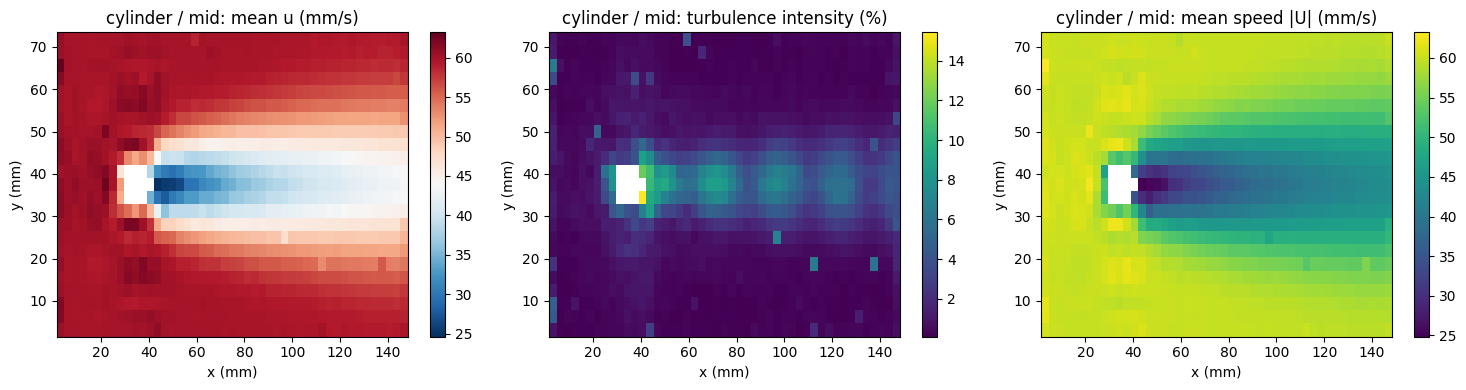

In [3]:
demo_case = ('cylinder', 'mid') if load_batch('cylinder', 'mid') is not None else first_available_case()
if demo_case is None:
    print("No processed case found yet -- run notebook 5 first, or wait for mutualized data.")
else:
    demo_flow, demo_regime = demo_case
    if demo_case != ('cylinder', 'mid'):
        print(f"('cylinder', 'mid') not available yet -- using {demo_flow}/{demo_regime} instead.")
    X, Y, U, V = load_batch(demo_flow, demo_regime)
    Umean, Vmean, Ustd, Vstd, speed_mean, tke_like = mean_std(U, V)
    U0 = 60.0 * REGIMES[demo_regime]
    turbulence_intensity = np.sqrt(2/3 * tke_like) / U0  # normalized by U0

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    for ax, field, title, cmap in [
        (axs[0], Umean, 'mean u (mm/s)', 'RdBu_r'),
        (axs[1], turbulence_intensity*100, 'turbulence intensity (%)', 'viridis'),
        (axs[2], speed_mean, 'mean speed |U| (mm/s)', 'viridis'),
    ]:
        pc = ax.pcolormesh(X, Y, field, shading='auto', cmap=cmap)
        plt.colorbar(pc, ax=ax)
        ax.set_title(f'{demo_flow} / {demo_regime}: {title}')
        ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    plt.tight_layout()
    plt.show()

Notice the turbulence intensity peaking exactly on the flanks of the mean
wake deficit — the signature of shear-driven fluctuations (here, mostly the
sampling of different shedding phases across realizations) rather than
measurement noise.

## 2. Vorticity

The out-of-plane vorticity $\omega_z = \partial v/\partial x - \partial
u/\partial y$ is computed from the mean field with a simple centered
finite difference (`numpy.gradient`), exactly the kind of derived quantity
requested in a PIV lab report.


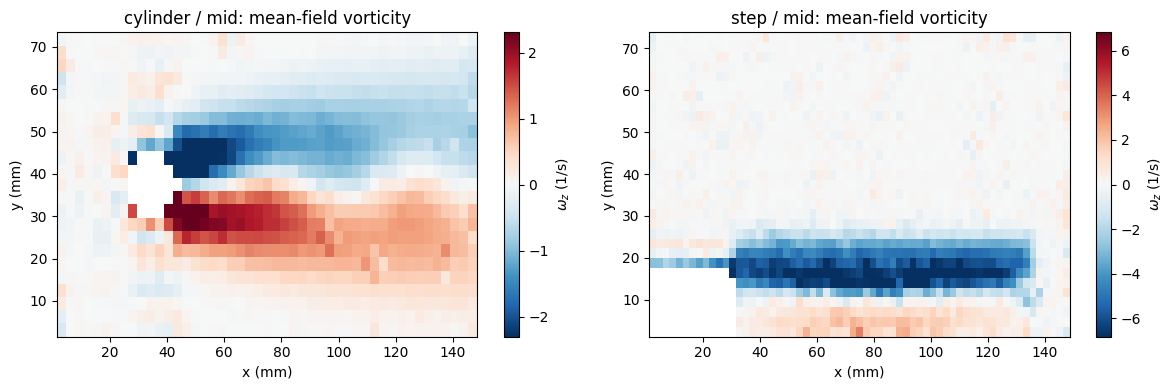

In [4]:
def vorticity(X, Y, U, V):
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    dVdx = np.gradient(V, dx, axis=1)
    dUdy = np.gradient(U, dy, axis=0)
    return dVdx - dUdy

to_plot = [flow for flow in ['cylinder', 'step'] if load_batch(flow, 'mid') is not None]
if not to_plot:
    print("Neither cylinder/mid nor step/mid is available yet.")
else:
    fig, axs = plt.subplots(1, len(to_plot), figsize=(6 * len(to_plot), 4), squeeze=False)
    for ax, flow in zip(axs[0], to_plot):
        Xf, Yf, Uf, Vf = load_batch(flow, 'mid')
        Um, Vm, *_ = mean_std(Uf, Vf)
        wz = vorticity(Xf, Yf, Um, Vm)
        vmax = np.nanpercentile(np.abs(wz), 98)
        pc = ax.pcolormesh(Xf, Yf, wz, shading='auto', cmap='RdBu_r',
                            vmin=-vmax, vmax=vmax)
        plt.colorbar(pc, ax=ax, label='$\\omega_z$ (1/s)')
        ax.set_title(f'{flow} / mid: mean-field vorticity')
        ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    plt.tight_layout()
    plt.show()

## 3. Case-specific diagnostics

### 3.1 Cylinder: wake velocity-deficit profile

We extract a cross-stream profile of the mean streamwise velocity a few
diameters downstream and read off the deficit relative to the free-stream
value — a standard way to characterize a wake.


cylinder / low: deficit at x=3D -> 42.5 % of U0
cylinder / mid: deficit at x=3D -> 43.3 % of U0
cylinder / high: deficit at x=3D -> 43.5 % of U0


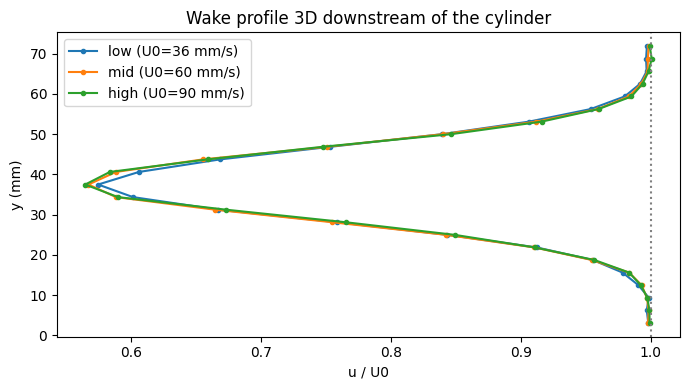

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for regime in REGIMES:
    batch = load_batch('cylinder', regime)
    if batch is None:
        print(f"cylinder / {regime}: not processed yet -- skipping")
        continue
    Xc, Yc, Uc, Vc = batch
    Um, *_ = mean_std(Uc, Vc)
    x_probe = CYL_X + 3 * CYL_D
    icol = np.argmin(np.abs(Xc[0, :] - x_probe))
    profile = Um[:, icol]
    y_profile = Yc[:, icol]
    U0 = 60.0 * REGIMES[regime]
    ax.plot(profile / U0, y_profile, marker='o', ms=3, label=f'{regime} (U0={U0:.0f} mm/s)')
    deficit = 1 - np.nanmin(profile) / U0
    print(f"cylinder / {regime}: deficit at x=3D -> {deficit*100:.1f} % of U0")
ax.axvline(1.0, color='gray', ls=':')
ax.set_xlabel('u / U0'); ax.set_ylabel('y (mm)')
ax.set_title('Wake profile 3D downstream of the cylinder')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Step: recirculation length

Along a row close to the wall, the recirculation bubble shows up as
negative mean streamwise velocity; the reattachment point is where it
crosses back to positive. We compare the estimate to the length used to
generate the synthetic data (`STEP_LR_MM`) — a validation you will *not*
be able to do on real data, but which confirms the method is sound before
you trust it there.


step / low: estimated reattachment x ~= 131 mm (Lr ~= 101 mm, design value = 105 mm)
step / mid: estimated reattachment x ~= 129 mm (Lr ~= 99 mm, design value = 105 mm)
step / high: estimated reattachment x ~= 124 mm (Lr ~= 94 mm, design value = 105 mm)


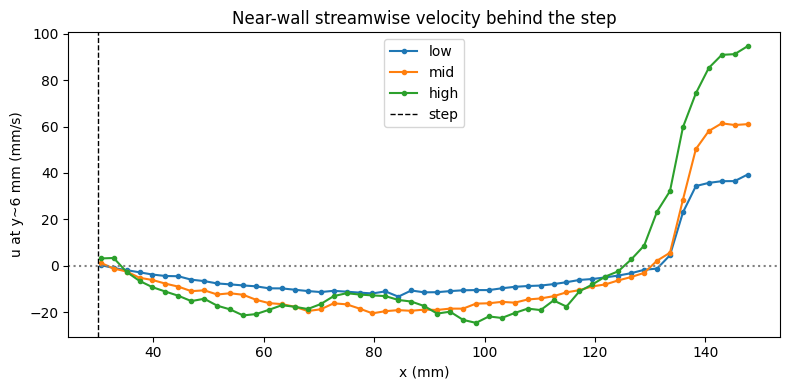

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for regime in REGIMES:
    batch = load_batch('step', regime)
    if batch is None:
        print(f"step / {regime}: not processed yet -- skipping")
        continue
    Xs, Ys, Us, Vs = batch
    Um, *_ = mean_std(Us, Vs)
    irow = np.argmin(np.abs(Ys[:, 0] - 0.4 * STEP_H))  # a row inside the bubble
    u_wall = Um[irow, :]
    x_wall = Xs[irow, :]
    ax.plot(x_wall, u_wall, marker='.', label=regime)

    downstream = x_wall > STEP_X
    sign_change = np.where(np.diff(np.sign(u_wall[downstream])) > 0)[0]
    if len(sign_change):
        x_reattach = x_wall[downstream][sign_change[0]]
        design_str = f", design value = {STEP_LR:.0f} mm" if STEP_LR is not None else ""
        print(f"step / {regime}: estimated reattachment x ~= {x_reattach:.0f} mm "
              f"(Lr ~= {x_reattach - STEP_X:.0f} mm{design_str})")
    else:
        print(f"step / {regime}: no reattachment point found -- the near-wall "
              f"recirculation was not resolved (see the invalid-vector "
              f"fraction for this case in notebook 5, section 7)")
ax.axhline(0, color='gray', ls=':')
ax.axvline(STEP_X, color='k', ls='--', lw=1, label='step')
ax.set_xlabel('x (mm)'); ax.set_ylabel(f'u at y~{0.4*STEP_H:.0f} mm (mm/s)')
ax.set_title('Near-wall streamwise velocity behind the step')
ax.legend()
plt.tight_layout()
plt.show()

> **The `step`/`high` regime originally failed to resolve the recirculation
> at all** (no sign crossing found): heavier reversed-flow gradients and more
> invalid vectors near the wall (see notebook 5, §7) let the
> outlier-replacement/smoothing step bias the near-wall velocity back
> towards the free-stream value instead of preserving the reversal.
> Notebook 5, §5 now uses a finer final interrogation window for the `step`
> flow specifically (48→24→12 px instead of the default 64→32→16 px) to
> better resolve the thin near-wall shear layer, and the recirculation is
> recovered at every regime — but note the measured length below is still
> comparatively less accurate at `high` than at `low`/`mid`, and §7's
> invalid-vector fraction is higher everywhere for `step` as a result of the
> finer window. Window-size choice near sharp gradients is a real
> resolution/noise trade-off, not just a knob to turn up universally.

## 4. Vortex shedding & Strouhal number

We probe the transverse velocity a few diameters downstream, look at its spectrum, and convert the dominant frequency into a Strouhal number $St = f_{shed} D / U_0$.

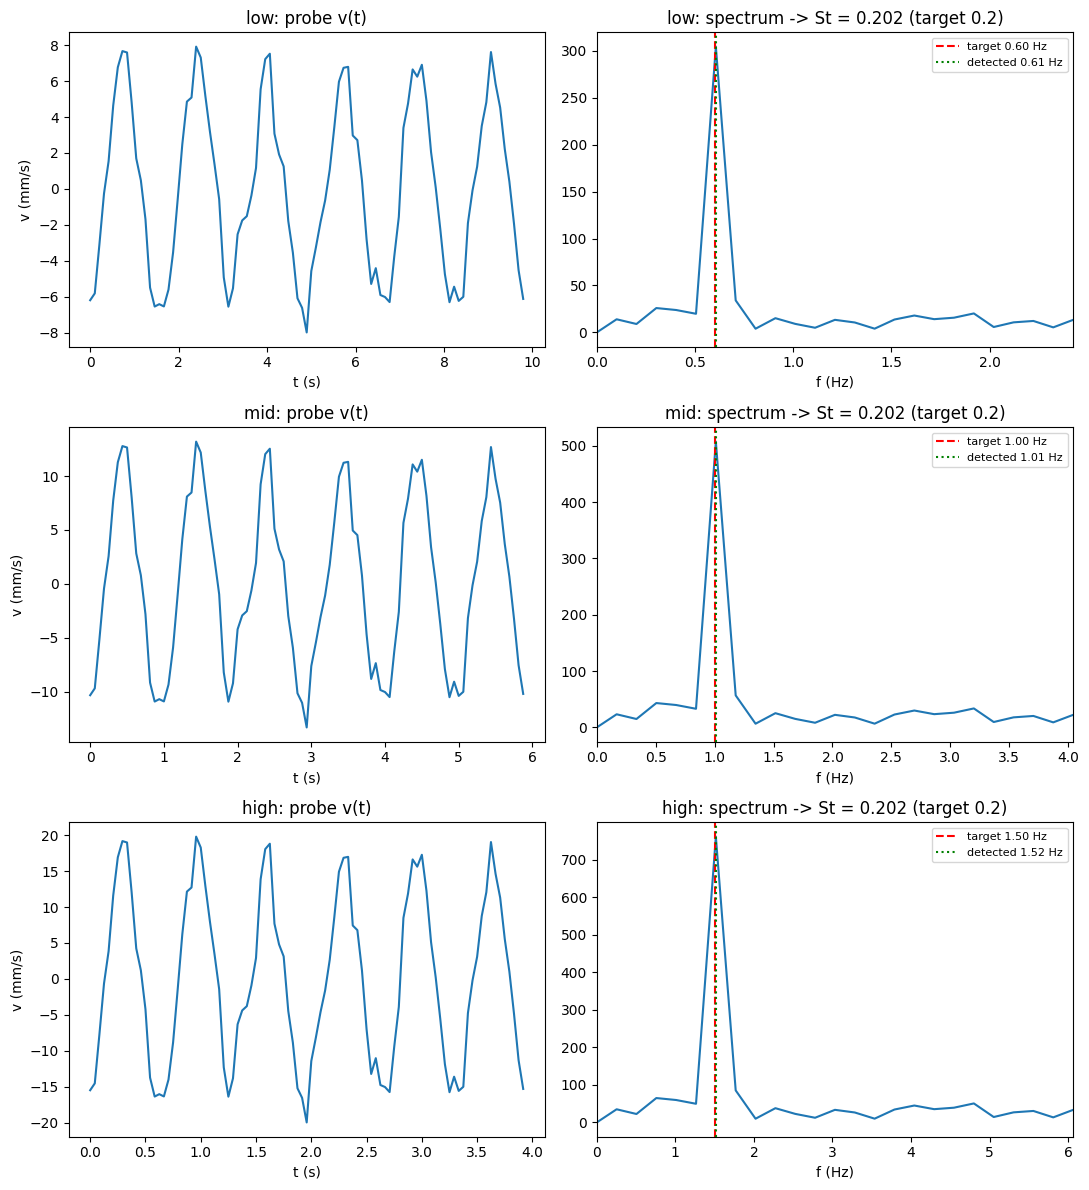


regime   St (measured)  St (target)
low              0.202         0.200
mid              0.202         0.200
high             0.202         0.200


In [7]:
def strouhal_from_timeresolved(regime):
    folder = RESULTS_ROOT / 'cylinder' / regime / 'OpenPIV_results_16_timeresolved'
    files = sorted(folder.glob('field_A*.txt'))
    if not files:
        return None
    x0 = y0 = None
    vt = []
    for f in files:
        data = np.loadtxt(f, skiprows=1)
        x, y, u, v, flags, mask = data.T
        if x0 is None:
            x0, y0 = x, y
            target_x = CYL_X + 3 * CYL_D
            target_y = CYL_Y if CYL_Y is not None else y0.mean()
            idx = np.argmin((x0 - target_x)**2 + (y0 - target_y)**2)
        vt.append(v[idx])
    vt = np.array(vt)

    if DATA_SOURCE == "synthetic":
        # dt_frame used during acquisition: recovered from shedding_frequency()
        # the same way notebook 5 built it (6 periods x 16 samples/period)
        f_target = shedding_frequency(regime)
        dt_frame = (1.0 / f_target) / 16
    else:
        f_target = None   # 🔁 unknown for real data -- that's what we're measuring
        dt_frame = DT_FRAME_REAL[regime]
        if dt_frame is None:
            raise ValueError(f"DT_FRAME_REAL['{regime}'] is not set -- match notebook 5 §1.")

    vt_detrend = vt - vt.mean()
    freqs = np.fft.rfftfreq(len(vt_detrend), d=dt_frame)
    spec = np.abs(np.fft.rfft(vt_detrend))
    f_peak = freqs[1:][np.argmax(spec[1:])]
    return vt, dt_frame, freqs, spec, f_peak, f_target

available_regimes = [r for r in REGIMES if strouhal_from_timeresolved(r) is not None]
if not available_regimes:
    print("No time-resolved cylinder sequence processed yet -- run notebook 5 §6 first.")
else:
    fig, axs = plt.subplots(len(available_regimes), 2, figsize=(11, 4 * len(available_regimes)), squeeze=False)
    St_values = {}
    for i, regime in enumerate(available_regimes):
        vt, dt_frame, freqs, spec, f_peak, f_target = strouhal_from_timeresolved(regime)
        t = np.arange(len(vt)) * dt_frame
        U0 = 60.0 * REGIMES[regime]
        St = f_peak * CYL_D / U0
        St_values[regime] = St

        axs[i, 0].plot(t, vt)
        axs[i, 0].set_title(f'{regime}: probe v(t)')
        axs[i, 0].set_xlabel('t (s)'); axs[i, 0].set_ylabel('v (mm/s)')

        axs[i, 1].plot(freqs, spec)
        if f_target is not None:
            axs[i, 1].axvline(f_target, color='r', ls='--', label=f'target {f_target:.2f} Hz')
        axs[i, 1].axvline(f_peak, color='g', ls=':', label=f'detected {f_peak:.2f} Hz')
        axs[i, 1].set_xlim(0, max(4 * f_peak, 4 * (f_target or f_peak)))
        st_target_str = f" (target {ST_TARGET})" if DATA_SOURCE == "synthetic" else ""
        axs[i, 1].set_title(f'{regime}: spectrum -> St = {St:.3f}{st_target_str}')
        axs[i, 1].set_xlabel('f (Hz)')
        axs[i, 1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"\n{'regime':6s} {'St (measured)':>15s}" + ("  St (target)" if DATA_SOURCE == "synthetic" else ""))
    for regime, St in St_values.items():
        line = f"{regime:6s} {St:15.3f}"
        if DATA_SOURCE == "synthetic":
            line += f" {ST_TARGET:13.3f}"
        print(line)

The Strouhal number comes out close to the design value at every regime —
the classic experimental observation that, over a wide range of moderate
Reynolds numbers, $St$ stays close to $0.2$ for a circular cylinder. On
real data, expect more scatter (finite sampling, 3D effects, background
turbulence) and use this as a sanity check on your probe location and
window length rather than an exact target.

## 5. Regime & flow comparison

Bringing the pieces together: Reynolds number, wake deficit and turbulence
intensity across the three flows and three regimes.


flow       regime  U0(mm/s)      Re   mean TI
free       low         36.0     540      0.8%
free       mid         60.0     900      0.8%
free       high        90.0    1350      0.8%
cylinder   low         36.0     432      1.6%
cylinder   mid         60.0     720      1.5%
cylinder   high        90.0    1080      1.3%
step       low         36.0     540      2.5%
step       mid         60.0     900      2.0%
step       high        90.0    1350      2.5%


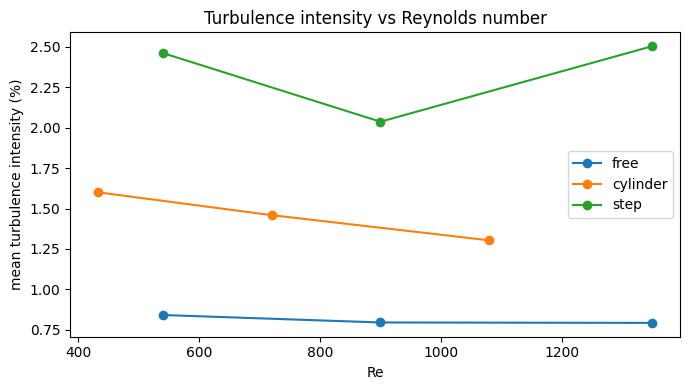

In [8]:
rows = []
for flow in FLOWS:
    for regime in REGIMES:
        batch = load_batch(flow, regime)
        if batch is None:
            print(f"{flow} / {regime}: not processed yet -- skipping")
            continue
        Xc, Yc, Uc, Vc = batch
        Um, Vm, Us, Vsd, speed_m, tke = mean_std(Uc, Vc)
        U0 = 60.0 * REGIMES[regime]
        TI = float(np.nanmean(np.sqrt(2/3 * tke)) / U0)
        Re = reynolds_number(flow, regime)
        rows.append((flow, regime, U0, Re, TI))

if not rows:
    print("No processed cases found yet -- run notebook 5 first.")
else:
    print(f"{'flow':10s} {'regime':6s} {'U0(mm/s)':>9s} {'Re':>7s} {'mean TI':>9s}")
    for flow, regime, U0, Re, TI in rows:
        print(f"{flow:10s} {regime:6s} {U0:9.1f} {Re:7.0f} {TI*100:8.1f}%")

    fig, ax = plt.subplots(figsize=(7, 4))
    for flow in FLOWS:
        Re_vals = [r[3] for r in rows if r[0] == flow]
        TI_vals = [r[4]*100 for r in rows if r[0] == flow]
        if not Re_vals:
            continue
        ax.plot(Re_vals, TI_vals, marker='o', label=flow)
    ax.set_xlabel('Re'); ax.set_ylabel('mean turbulence intensity (%)')
    ax.set_title('Turbulence intensity vs Reynolds number')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Discussion — for your report

- How does the wake deficit and the recirculation length
  change with regime? Is that consistent with your expectation for increasing Reynolds number?
- The turbulence intensity estimate mixes true unsteadiness with the realization-to-realization sampling of different shedding phases — how would you separate the two on **time-resolved** data instead of independent realizations?
- The Strouhal number was essentially constant across regimes here —
  is that still true on your real data? What would make it vary (blockage ratio, free-surface effects, 3D end effects in the aquarium)?
- Compare the three flows at the same regime: how does the free-stream
  case help you separate "true" flow features from PIV processing artifacts (window size, validation thresholds) in the cylinder and step cases?
- Revisit the image-quality diagnostics: for your real
  images, do particle density/size vary across flows or regimes to bias these comparisons?
